# Fabricar un medicamento contra el cáncer... en levadura

El etopósido es de los primeros medicamentos que le dan a alguien con cáncer de pulmón de células pequeñas. Y hoy, para fabricarlo, hay que arrancar una planta del Himalaya que está en peligro de extinción.

Un equipo probó otra ruta: meterle a la levadura de cerveza las instrucciones genéticas de esa planta, para que el precursor del fármaco salga de un tanque y no de un bosque.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

---

**Paper:** *Enabling sustainable supply of the essential cancer medicines etoposide and teniposide in yeast* · Shen et al., **Science** (2026)
**DOI:** [10.1126/science.aef5438](https://doi.org/10.1126/science.aef5438)
[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-31-etoposido-teniposido-levadura/notebook.ipynb)
**Video:** [Ver en YouTube](https://youtube.com/shorts/3FS8UWSDAic)

## ¿Por qué esto es difícil?

El etopósido y el tenipósido no se sintetizan de cero en un laboratorio químico: se parte de un precursor que solo produce una planta, el *Sinopodophyllum hexandrum*. Extraerlo presiona a una especie que ya está amenazada.

La idea del equipo fue reconstruir *dentro de la levadura* la cadena de enzimas que la planta usa para armar esa molécula. En números: más de **60 ediciones genéticas** y **45 enzimas** de otros organismos, metidas en *Saccharomyces cerevisiae* — la misma levadura del pan y la cerveza. Al final, un único paso químico convierte el precursor en el fármaco.

Aquí abrimos los datos crudos del paper (Data S4) y seguimos el camino que recorrieron para subir el rendimiento.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_DATOS      = '#2563EB'   # Azul CaM — datos principales
COLOR_ALERTA     = '#DC2626'   # Rojo — el objetivo real (lo difícil)
COLOR_SECUNDARIO = '#059669'   # Emerald — segunda serie
COLOR_REFERENCIA = '#D97706'   # Amber — umbral / baseline
COLOR_CONTEXTO   = '#BBBBBB'   # Gris — contexto
FUENTE = 'Fuente: Shen et al. (2026), Science | Datos: Supplementary Data S4'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo CaM (local → fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de los 4 CSVs (Data S4)
b  = pd.read_csv('datos/fig3b_car_screening.csv')      # tamizaje de enzimas CAR
d  = pd.read_csv('datos/fig3d_strain_iteration.csv')   # iteración de cepas
f4 = pd.read_csv('datos/fig4_dir_tradeoff.csv')        # balance de flujo CAL <-> PIN
f5 = pd.read_csv('datos/fig5_final_titers.csv')        # panel final de lignanos

# El compuesto 28 (objetivo del etopósido) aparece en dos cepas;
# nos quedamos con la mejor de cada compuesto.
f5_best = f5.sort_values('titer_ug_L', ascending=False).drop_duplicates('compound_name')

print('CAR tamizadas (Fig 3B):', len(b) - 1, 'enzimas + referencia')
print('Cepas iteradas (Fig 3D):', len(d))
print('Compuestos finales (Fig 5):', f5_best['compound_name'].nunique())
print()
print('Objetivo real (comp 28) — mejor cepa:',
      round(f5[f5.compound_num == 28].titer_ug_L.max(), 1), 'ug/L')
print('Glucósido estrella (comp 25):',
      round(f5[f5.compound_num == 25].titer_ug_L.max(), 1), 'ug/L')

CAR tamizadas (Fig 3B): 5 enzimas + referencia
Cepas iteradas (Fig 3D): 9
Compuestos finales (Fig 5): 12

Objetivo real (comp 28) — mejor cepa: 132.2 ug/L
Glucósido estrella (comp 25): 1620.0 ug/L


## El resultado

La levadura terminó produciendo doce lignanos distintos (trece mediciones: el compuesto 28 salió en dos cepas distintas). Aquí están, ordenados por cuánto salió de cada uno.

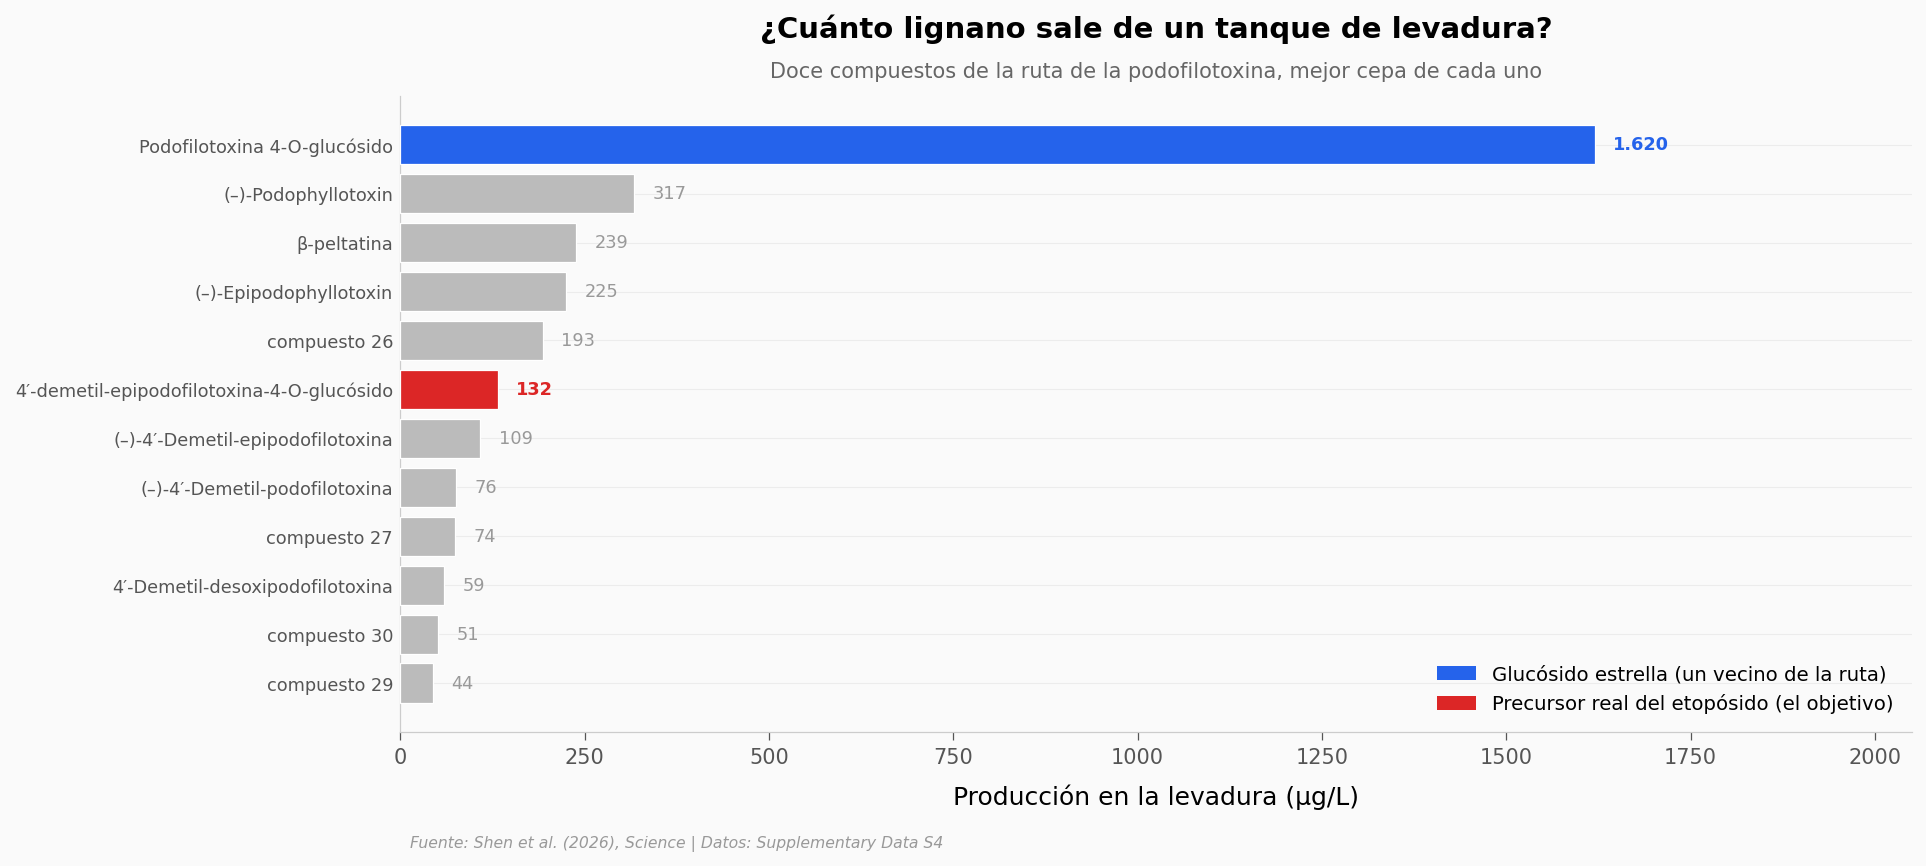

In [2]:
# Panel final: cuánto produjo la levadura de cada lignano (mejor cepa por compuesto)
datos = f5_best.sort_values('titer_ug_L', ascending=True)
nombres = datos['compound_name'].values
valores = datos['titer_ug_L'].values
comp_num = datos['compound_num'].values

# Colorear: estrella (25) en azul, objetivo real del etopósido (28) en rojo, resto gris
colores = []
for cn in comp_num:
    if cn == 25:
        colores.append(COLOR_DATOS)
    elif cn == 28:
        colores.append(COLOR_ALERTA)
    else:
        colores.append(COLOR_CONTEXTO)

fig, ax = plt.subplots(figsize=(13, 5.5))
y = np.arange(len(nombres))
ax.barh(y, valores, color=colores, edgecolor='white', linewidth=0.6, zorder=3)
ax.set_yticks(y)
ax.set_yticklabels(nombres, fontsize=8.5)
ax.set_xlabel('Producción en la levadura (µg/L)')
ax.set_title('¿Cuánto lignano sale de un tanque de levadura?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Doce compuestos de la ruta de la podofilotoxina, mejor cepa de cada uno',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Etiquetas de valor al final de cada barra
for yi, v, cn in zip(y, valores, comp_num):
    txt = f'{v:,.0f}'.replace(',', '.')
    ax.text(v + 25, yi, txt, va='center', fontsize=8.5,
            color=(COLOR_DATOS if cn == 25 else COLOR_ALERTA if cn == 28 else '#999999'),
            fontweight=('bold' if cn in (25, 28) else 'normal'))

# Leyenda de 2 entradas (identificar las dos barras destacadas sin encimar los números)
from matplotlib.patches import Patch
leyenda = [Patch(facecolor=COLOR_DATOS, label='Glucósido estrella (un vecino de la ruta)'),
           Patch(facecolor=COLOR_ALERTA, label='Precursor real del etopósido (el objetivo)')]
ax.legend(handles=leyenda, fontsize=9.5, loc='lower right', framealpha=0.9)

ax.set_xlim(0, 2050)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/panel_final.png', dpi=200, bbox_inches='tight')
plt.show()

El compuesto que más salió no es el que buscaban. El glucósido estrella llegó a **1.620 µg/L**, pero el precursor que de verdad alimenta al etopósido — el 4′-demetil-epipodofilotoxina-4-*O*-glucósido — se quedó en **132 µg/L**.

Esa distancia importa: la ruta rinde de sobra en un punto vecino y flojo justo donde tiene que rendir. Lo guardamos para el cierre; primero veamos cómo llegaron hasta aquí.

## El camino: dos palancas para subir el rendimiento

Antes del panel final, el equipo tuvo que hacer que la levadura produjera bien el primer eslabón: el alcohol coniferílico (CAL), el ladrillo del que se arma todo lo demás. Dos jugadas movieron la aguja.

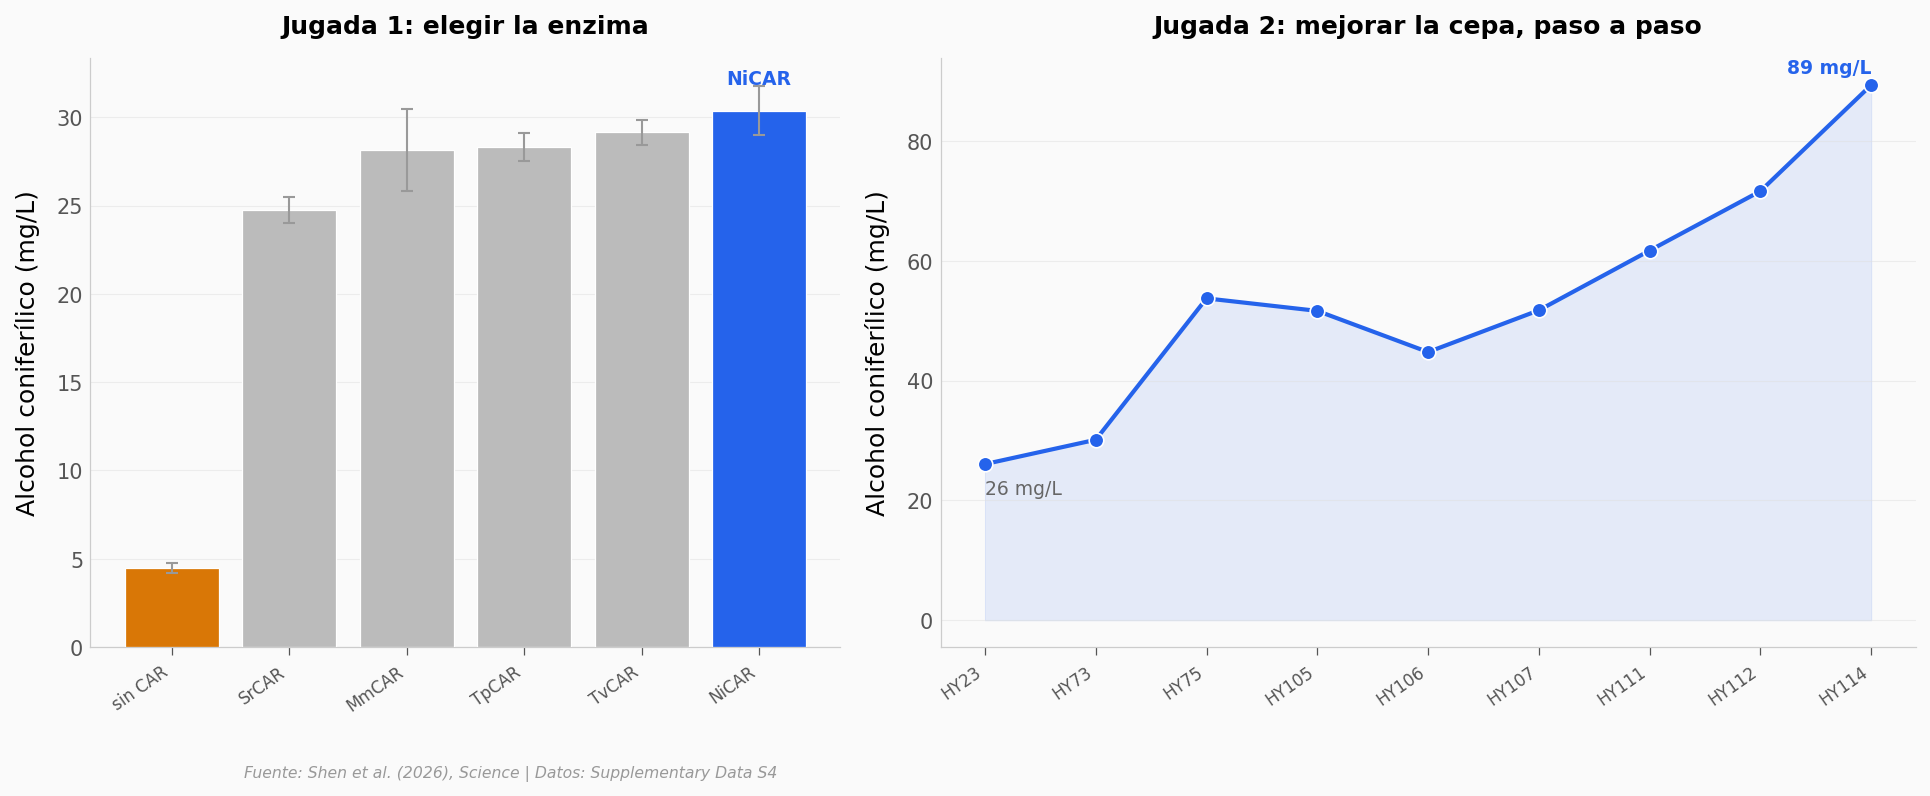

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [1, 1.3]})

# --- Panel izquierdo: tamizaje de enzimas CAR (Fig 3B) ---
b_sorted = b.sort_values('cal_titer_mg_L')
enzimas = [e.split('/')[-1].strip() if s == 'HY06' else s2
           for e, s, s2 in zip(b_sorted['enzyme_genes'], b_sorted['strain'], b_sorted['enzyme_genes'])]
etiquetas = ['sin CAR' if s == 'HY06' else g for s, g in zip(b_sorted['strain'], b_sorted['enzyme_genes'])]
colores_b = [COLOR_REFERENCIA if s == 'HY06' else
             (COLOR_DATOS if v == b['cal_titer_mg_L'].max() else COLOR_CONTEXTO)
             for s, v in zip(b_sorted['strain'], b_sorted['cal_titer_mg_L'])]
xb = np.arange(len(b_sorted))
ax1.bar(xb, b_sorted['cal_titer_mg_L'], yerr=b_sorted['stdev'],
        color=colores_b, edgecolor='white', linewidth=0.6,
        error_kw=dict(ecolor='#999999', capsize=3, lw=1), zorder=3)
ax1.set_xticks(xb)
ax1.set_xticklabels(etiquetas, rotation=35, ha='right', fontsize=8)
ax1.set_ylabel('Alcohol coniferílico (mg/L)')
ax1.set_title('Jugada 1: elegir la enzima', fontsize=12, fontweight='bold', pad=12)
ax1.text(list(b_sorted['strain']).index('HY16'), 30.4 + 1.5, 'NiCAR',
         ha='center', fontsize=9, color=COLOR_DATOS, fontweight='bold')

# --- Panel derecho: iteración de cepas (Fig 3D) ---
xd = np.arange(len(d))
ax2.plot(xd, d['cal_titer_mg_L'], '-o', color=COLOR_DATOS, markersize=7,
         markeredgecolor='white', markeredgewidth=0.8, linewidth=2, zorder=5)
ax2.fill_between(xd, d['cal_titer_mg_L'], alpha=0.10, color=COLOR_DATOS)
ax2.set_xticks(xd)
ax2.set_xticklabels(d['strain'], rotation=35, ha='right', fontsize=8)
ax2.set_ylabel('Alcohol coniferílico (mg/L)')
ax2.set_title('Jugada 2: mejorar la cepa, paso a paso', fontsize=12, fontweight='bold', pad=12)
ax2.text(0, d['cal_titer_mg_L'].iloc[0] - 5, '26 mg/L', fontsize=9, color='#666666')
ax2.text(len(d) - 1, d['cal_titer_mg_L'].iloc[-1] + 2, '89 mg/L',
         ha='right', fontsize=9, color=COLOR_DATOS, fontweight='bold')

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/camino.png', dpi=200, bbox_inches='tight')
plt.show()

## Y aquí se complica

Subir el primer eslabón no basta. Para avanzar hacia la podofilotoxina, la ruta necesita una proteína "dirigente" (ScDIR) que tuerce dos moléculas y forma el pinoresinol. El problema: esa misma reacción *consume* el alcohol coniferílico que tanto costó acumular.

Así que el equipo probó a meter distintas cantidades de esa proteína — de 0 a 8 copias del gen — para ver dónde queda el balance.

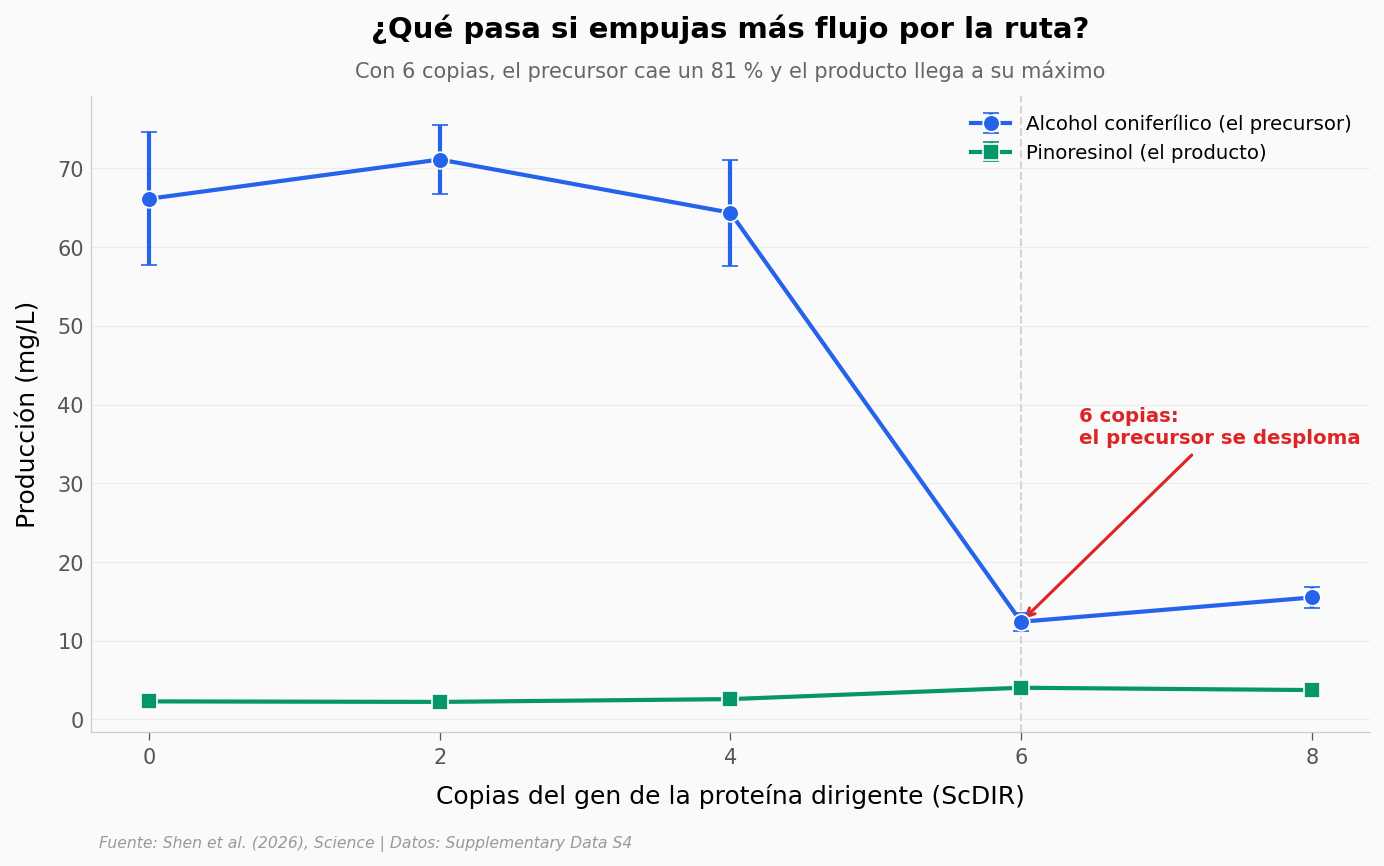

In [4]:
# Balance de flujo: más proteína dirigente vacía el precursor y llena el producto
fig, ax = plt.subplots(figsize=(11, 5.5))
x = f4['scdir_copies']

ax.errorbar(x, f4['cal_titer_mg_L'], yerr=f4['cal_stdev'], fmt='-o',
            color=COLOR_DATOS, markersize=8, markeredgecolor='white',
            markeredgewidth=0.8, linewidth=2, capsize=4, zorder=5,
            label='Alcohol coniferílico (el precursor)')
ax.errorbar(x, f4['pin_titer_mg_L'], yerr=f4['pin_stdev'], fmt='-s',
            color=COLOR_SECUNDARIO, markersize=8, markeredgecolor='white',
            markeredgewidth=0.8, linewidth=2, capsize=4, zorder=5,
            label='Pinoresinol (el producto)')

ax.set_xlabel('Copias del gen de la proteína dirigente (ScDIR)')
ax.set_ylabel('Producción (mg/L)')
ax.set_xticks(x)
ax.set_title('¿Qué pasa si empujas más flujo por la ruta?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Con 6 copias, el precursor cae un 81 % y el producto llega a su máximo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Marcar el punto de 6 copias
ax.axvline(x=6, color=COLOR_CONTEXTO, linestyle='--', linewidth=1, alpha=0.6, zorder=1)
ax.annotate('6 copias:\nel precursor se desploma', xy=(6, 12.4), xytext=(6.4, 35),
            fontsize=9.5, color=COLOR_ALERTA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax.legend(fontsize=9.5, loc='upper right', framealpha=0.9)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/tradeoff.png', dpi=200, bbox_inches='tight')
plt.show()

## El dato honesto

Volvamos al panel final. La levadura fabrica de sobra el glucósido estrella. Pero el precursor que de verdad se convierte en etopósido — la molécula que justifica todo el proyecto — sale 12 veces menos que ese vecino que sí sobra. ¿Cuánta es esa diferencia?

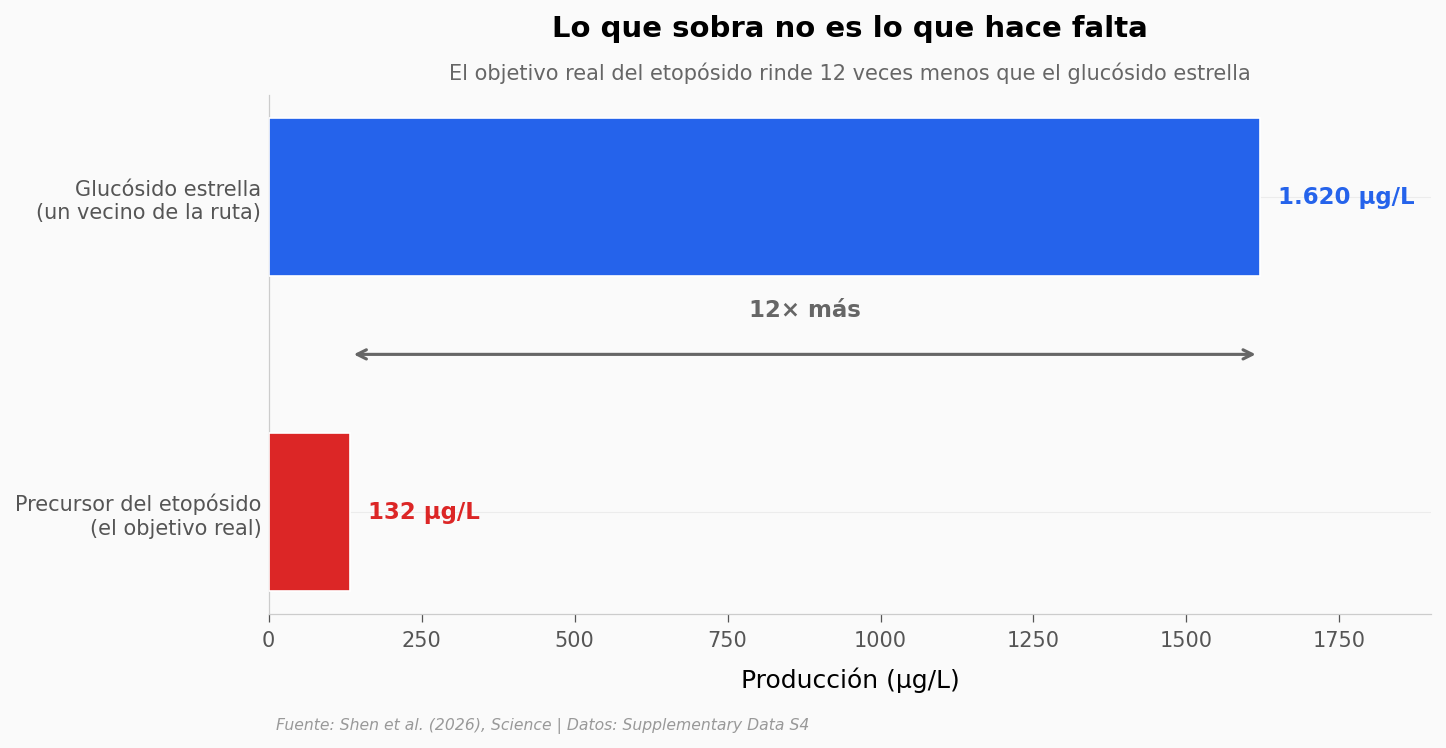

In [5]:
# La brecha: lo que sale fácil vs. lo que hace falta (escala lineal)
star = f5[f5.compound_num == 25].titer_ug_L.max()
target = f5[f5.compound_num == 28].titer_ug_L.max()
ratio = star / target

fig, ax = plt.subplots(figsize=(10, 4.5))
etiquetas = ['Glucósido estrella\n(un vecino de la ruta)',
             'Precursor del etopósido\n(el objetivo real)']
valores = [star, target]
colores = [COLOR_DATOS, COLOR_ALERTA]
y = [1, 0]
ax.barh(y, valores, color=colores, edgecolor='white', linewidth=0.8,
        height=0.5, zorder=3)
ax.set_yticks(y)
ax.set_yticklabels(etiquetas, fontsize=10)
ax.set_xlabel('Producción (µg/L)')
for yi, v in zip(y, valores):
    ax.text(v + 30, yi, f'{v:,.0f}'.replace(',', '.') + ' µg/L',
            va='center', fontsize=11, fontweight='bold',
            color=(COLOR_DATOS if yi == 1 else COLOR_ALERTA))

# Flecha bidireccional mostrando la brecha (escala lineal: el hueco se ve real)
ax.annotate('', xy=(star, 0.5), xytext=(target, 0.5),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((star + target) / 2, 0.62, f'{ratio:.0f}× más',
        ha='center', fontsize=11, color='#666666', fontweight='bold')

ax.set_title('Lo que sobra no es lo que hace falta',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'El objetivo real del etopósido rinde 12 veces menos que el glucósido estrella',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0, 1900)
fig.text(0.13, -0.06, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/brecha.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Añadir una enzima CAR sube el precursor ~6,8× | ✅ | De 4,47 a 30,4 mg/L (mejor de 5 enzimas, NiCAR). Data S4, Fig 3B |
| Iterar la cepa la sube otras 3,4× | ✅ | De 26,1 a 89,4 mg/L a lo largo de 9 cepas. Data S4, Fig 3D |
| La proteína dirigente crea un dilema de flujo | ✅ | Con 6 copias el precursor cae 81 % (66→12 mg/L) y el pinoresinol llega a su máximo (4,01 mg/L, 1,76×). Data S4, Fig 4 |
| El precursor real del etopósido rinde 12× menos que el glucósido estrella vecino | ✅ | 132 µg/L vs 1.620 µg/L. Queda a media tabla (7.º de 12), no es el mínimo. Data S4, Fig 5 |

> **Limitaciones:** son concentraciones medidas en una sola tanda de fermentación por cepa (con réplicas técnicas y su desviación estándar), no rendimientos a escala industrial. El paper *reconstruye y mide* un sistema — es una prueba de concepto de la ruta, no una demostración de que ya se pueda abastecer el mercado. El paso químico final que convierte el precursor en etopósido no se cuantifica aquí. Y el objetivo real (compuesto 28) sigue siendo el cuello de botella: la ruta aún no lo produce de forma abundante.

## Ahora tú

1. **¿Y si la proteína dirigente costara menos precursor?** Mira la curva de la Fig 4: el pinoresinol sube poco (1,76×) mientras el precursor se desploma (−81 %). ¿En qué número de copias pondrías tú el equilibrio? Prueba graficando la *razón* pinoresinol/precursor para cada punto.

2. **¿Cuánto pesa cada jugada?** La enzima CAR dio 6,8× y la iteración de cepas 3,4×. ¿Cuál fue el multiplicador total desde el punto de partida sin CAR? (Pista: no siempre se multiplican directamente — las cepas parten de otro punto.)

3. **¿Qué compuesto está más cerca del fármaco?** En el panel final, busca los compuestos glucosilados (los que terminan en *glucósido*) y compáralos con sus versiones sin azúcar. ¿La glucosilación ayuda o estorba al rendimiento?

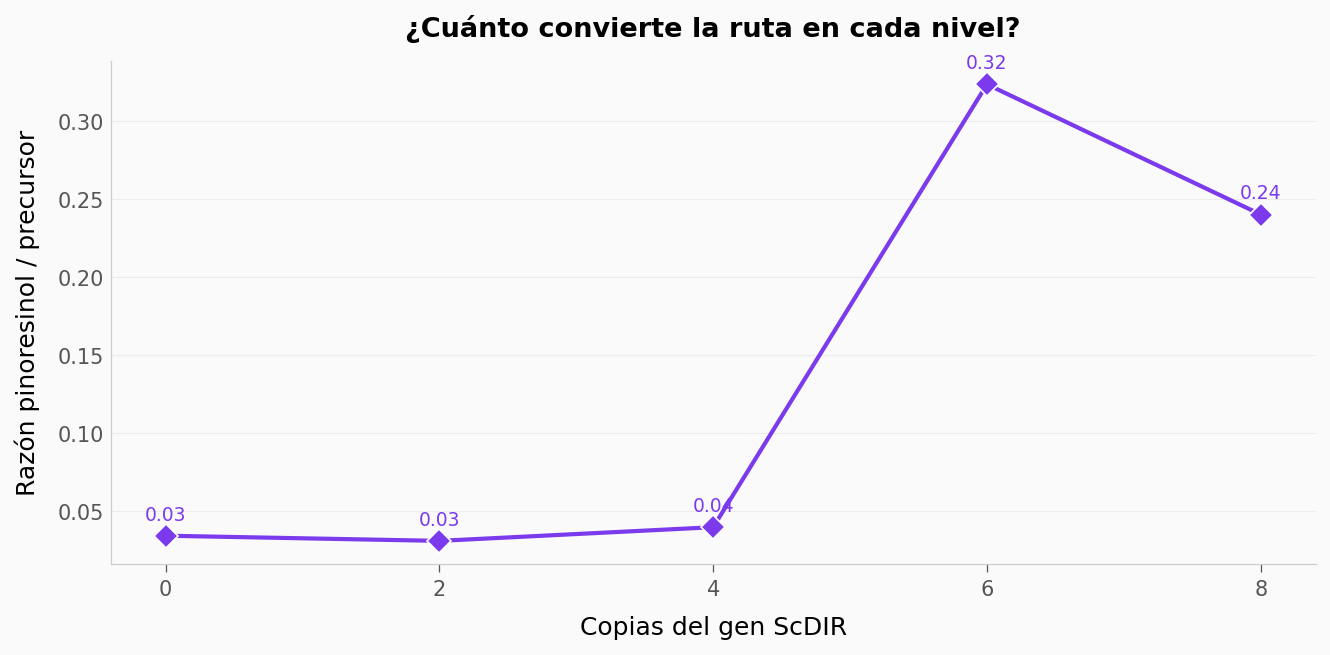

La razón crece con más copias, pero a costa del precursor total.
Máxima conversión relativa en 6 copias — justo donde el precursor casi se agota.


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿dónde está el mejor equilibrio entre producto y precursor?
# La razón pinoresinol / alcohol coniferílico nos dice cuánto "convierte"
# la ruta en cada nivel de proteína dirigente.

f4_exp = f4.copy()
f4_exp['razon_pin_cal'] = f4_exp['pin_titer_mg_L'] / f4_exp['cal_titer_mg_L']

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(f4_exp['scdir_copies'], f4_exp['razon_pin_cal'], '-D',
        color='#7C3AED', markersize=8, markeredgecolor='white',
        markeredgewidth=0.8, linewidth=2, zorder=5)
ax.set_xlabel('Copias del gen ScDIR')
ax.set_ylabel('Razón pinoresinol / precursor')
ax.set_xticks(f4_exp['scdir_copies'])
ax.set_title('¿Cuánto convierte la ruta en cada nivel?',
             fontsize=13, fontweight='bold', pad=12)
for xc, r in zip(f4_exp['scdir_copies'], f4_exp['razon_pin_cal']):
    ax.text(xc, r + 0.01, f'{r:.2f}', ha='center', fontsize=9, color='#7C3AED')
plt.tight_layout()
plt.show()

print('La razón crece con más copias, pero a costa del precursor total.')
print('Máxima conversión relativa en', int(f4_exp.loc[f4_exp.razon_pin_cal.idxmax(), 'scdir_copies']),
      'copias — justo donde el precursor casi se agota.')

## Fuentes

**Paper**: [Enabling sustainable supply of the essential cancer medicines etoposide and teniposide in yeast](https://doi.org/10.1126/science.aef5438)  
*Science, 2026-07-30*

**Supplementary Material**: [Data S4 — datos crudos de todas las figuras](https://www.science.org/doi/suppl/10.1126/science.aef5438/suppl_file/science.aef5438_data_s1_to_s5.zip)  
*Science, mismo DOI*

*24 afirmaciones del notebook verificadas contra estas fuentes*